In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Carrega datasets não processado e processado e retira comentarios vazios.

In [79]:
dataset_base = "comments_dataset.csv"
dataset_processed = "comments_dataset_processed.csv"

df_base = pd.read_csv(dataset_base)
df_processed = pd.read_csv(dataset_processed)

df_base['commentText'] = df_base['commentText'].astype(str).fillna('')
df_processed['cleanedText'] = df_processed['cleanedText'].astype(str).fillna('')

## Estatísticas gerais

In [80]:
def general_statics(df):
    total_comments = len(df)
    total_videos = df['videoId'].nunique()
    total_authors = df['authorChannelId'].nunique()
    mean_comments_video = df.groupby('videoId').size().mean()
    mean_comments_author = df.groupby('authorChannelId').size().mean()

    print(f"Total de Comentários: {total_comments}")
    print(f"Total de Vídeos Analisados: {total_videos}")
    print(f"Total de Autores Únicos: {total_authors}")
    print(f"Média de Comentários por Vídeo: {mean_comments_video:.2f}")
    print(f"Média de Comentários por Autor: {mean_comments_author:.2f}")

In [81]:
print("Gerando estatisticas do dataset não processado:")
general_statics(df_base)
print()

print("Gerando estatísticas do dataset processado")
general_statics(df_processed)

Gerando estatisticas do dataset não processado:
Total de Comentários: 754159
Total de Vídeos Analisados: 6462
Total de Autores Únicos: 547088
Média de Comentários por Vídeo: 116.71
Média de Comentários por Autor: 1.38

Gerando estatísticas do dataset processado
Total de Comentários: 741863
Total de Vídeos Analisados: 6447
Total de Autores Únicos: 539298
Média de Comentários por Vídeo: 115.07
Média de Comentários por Autor: 1.38


## Distribuição de Comentários por Vídeo

In [82]:
def comment_distribution_video(df):
    comments_per_video = df['videoId'].value_counts().reset_index()
    comments_per_video.columns = ['videoId', 'qtd_comments']

    return comments_per_video

In [83]:
print("Distribuição de comentários por video no dataset não processado:")
comments_vid_base = comment_distribution_video(df_base)
print("\nTop 10 Vídeos por Quantidade de Comentários:")
print(comments_vid_base.head(10))
print()

print("Distribuição de comentários por video no dataset processado:")
comments_vid_processed = comment_distribution_video(df_processed)
print("\nTop 10 Vídeos por Quantidade de Comentários:")
print(comments_vid_processed.head(10))

Distribuição de comentários por video no dataset não processado:

Top 10 Vídeos por Quantidade de Comentários:
       videoId  qtd_comments
0  Luuxbx8pvwY          1000
1  r1HqZ73BEmQ          1000
2  TScV4wd_0aQ          1000
3  N8Xwo2avSco          1000
4  TGcS4hJskU0          1000
5  Pr5SPN0lsPo          1000
6  AH2JImEb44c          1000
7  GIy0D3ZKkj0          1000
8  CbAojmwoXwA          1000
9  EynhnYNmP54          1000

Distribuição de comentários por video no dataset processado:

Top 10 Vídeos por Quantidade de Comentários:
       videoId  qtd_comments
0  cVRTbLicBGA          1000
1  PfYkuAVsg1M          1000
2  FOVfyINLcV8          1000
3  CHbp_0sIg28          1000
4  MAwwocBjxoY          1000
5  Yet8JIj4Ulg          1000
6  YpXvnGQ2I34          1000
7  S-ehAIiisLQ          1000
8  oN1wHpqvgsY           999
9  LVExfEtteno           999


### Scatter plot

In [84]:
def scatterplot_comments_video(df, comments_per_video):
    plt.figure(figsize=(12, 6))

    # índice no eixo X e a quantidade no eixo Y
    plt.scatter(comments_per_video.index, comments_per_video['qtd_comments'], 
                alpha=0.6, c='royalblue', edgecolors='w', s=50)

    # linha de média para referência
    media = comments_per_video['qtd_comments'].mean()
    plt.axhline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')

    plt.title('Distribuição de Quantidade de Comentários por Vídeo', fontsize=15)
    plt.xlabel('Vídeos (Índice Ordenado)', fontsize=12)
    plt.ylabel('Total de Comentários', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

Gráfico scatter plot de distribuição de comentários por video no dataset não processado:


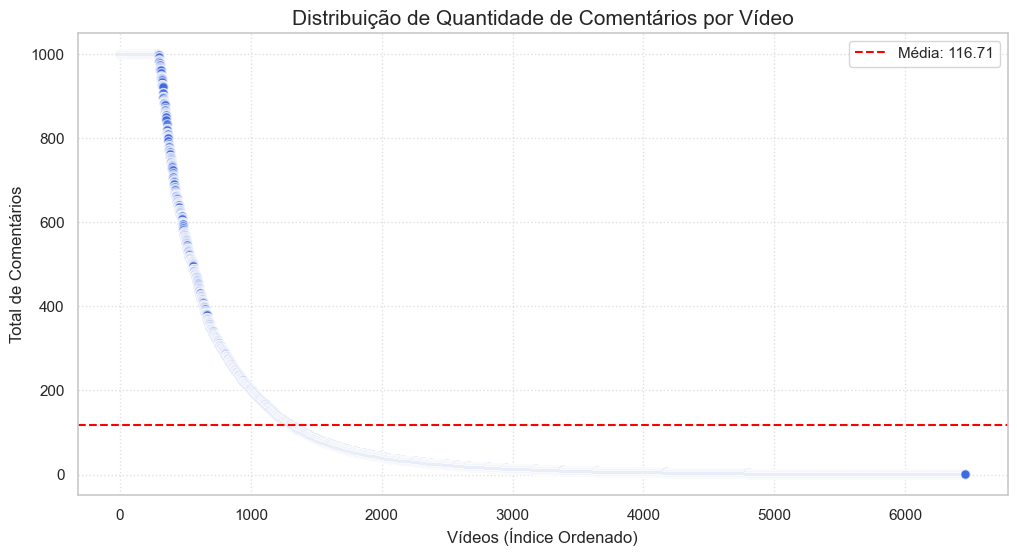


Gráfico scatter plot de distribuição de comentários por video no dataset processado:


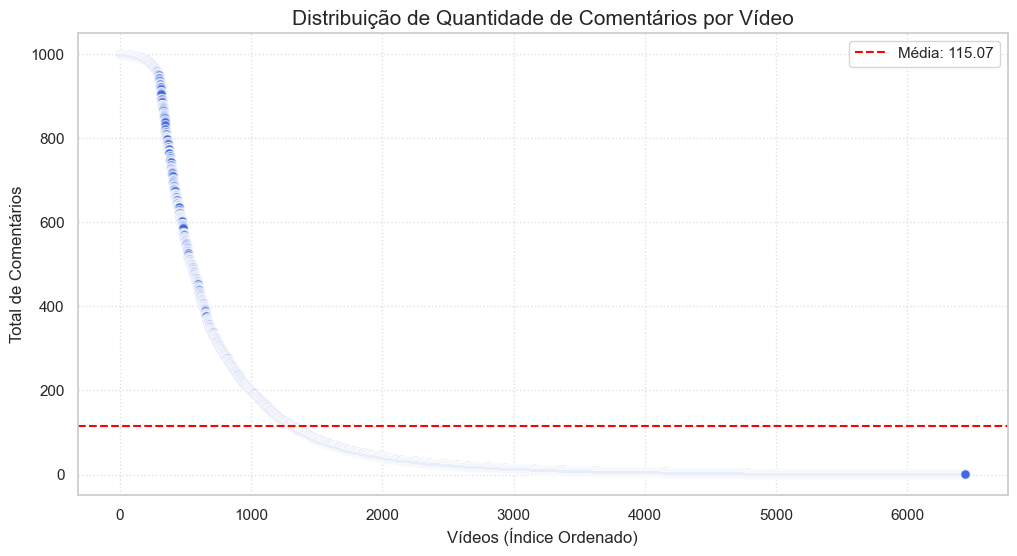

In [85]:
print("Gráfico scatter plot de distribuição de comentários por video no dataset não processado:")
scatterplot_comments_video(df_base, comments_vid_base)
print()

print("Gráfico scatter plot de distribuição de comentários por video no dataset processado:")
scatterplot_comments_video(df_processed, comments_vid_processed)

### Strip Plot

In [49]:
def stripplot_comments_vid(df, comments_per_video):
    plt.figure(figsize=(6, 8))
    sns.stripplot(y=comments_per_video['qtd_comments'], color='purple', alpha=0.5, jitter=True)
    plt.title('Concentração de Comentários')
    plt.ylabel('Qtd de Comentários por Vídeo')
    plt.show()

Gráfico strip plot de distribuição de comentários por video no dataset não processado:


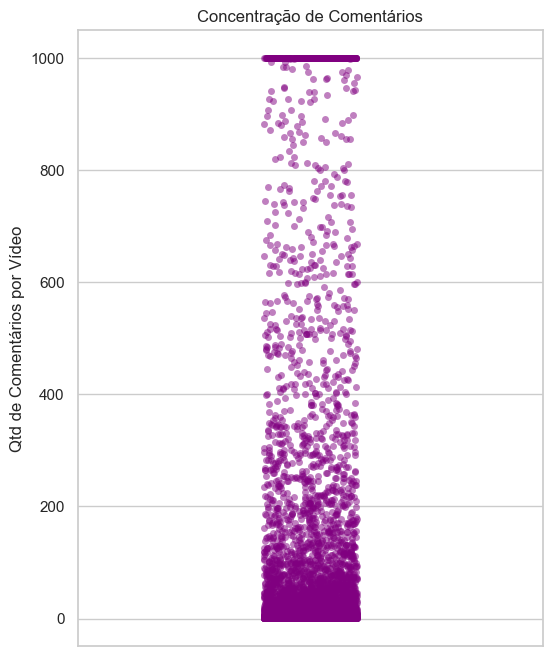


Gráfico scatter plot de distribuição de comentários por video no dataset processado:


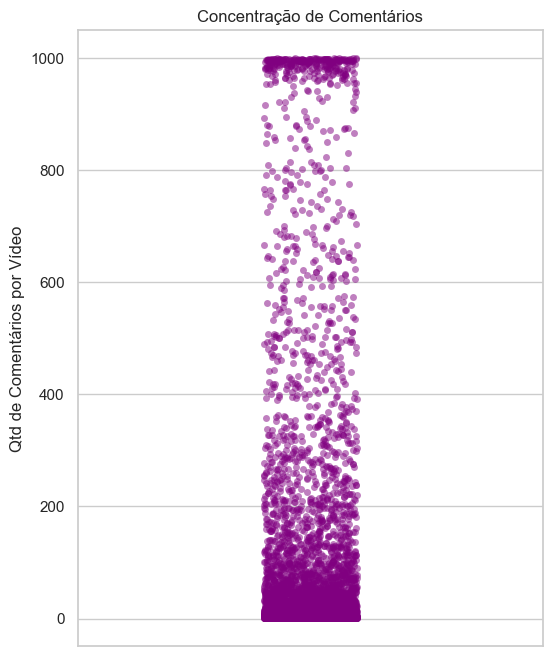

In [86]:
print("Gráfico strip plot de distribuição de comentários por video no dataset não processado:")
stripplot_comments_vid(df_base, comments_vid_base)
print()

print("Gráfico scatter plot de distribuição de comentários por video no dataset processado:")
stripplot_comments_vid(df_processed, comments_vid_processed)

## Análise de Frequência Temporal

In [87]:

def temporal_freq_graph(df):
    comments_per_day = df.resample('D', on='commentPublishedAt').size()

    plt.figure(figsize=(12, 5))
    comments_per_day.plot(kind='line', marker='o', color='red')
    plt.title('Quantidade de Comentários Postados por Dia')
    plt.xlabel('Data')
    plt.ylabel('Número de Comentários')
    plt.grid(True)
    plt.show()

Gráfico de frequência temporal no dataset não processado:


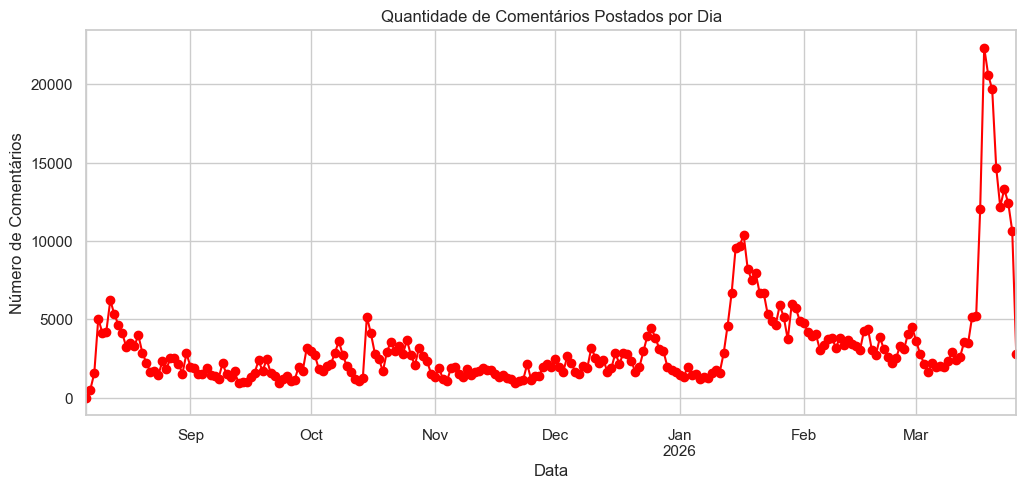


Gráfico de frequência temporal no dataset processado:


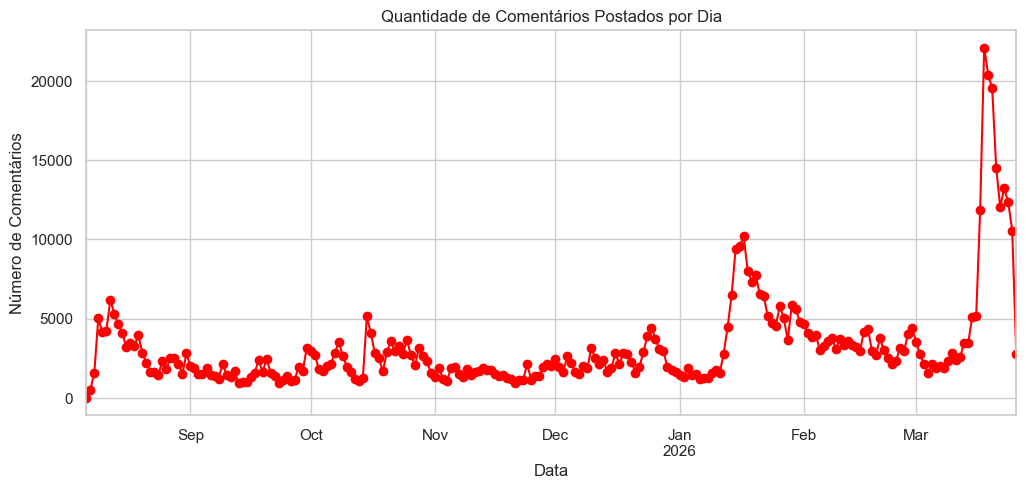

In [88]:
df_base['commentPublishedAt'] = pd.to_datetime(df_base['commentPublishedAt'])
df_processed['commentPublishedAt'] = pd.to_datetime(df_processed['commentPublishedAt'])

print("Gráfico de frequência temporal no dataset não processado:")
temporal_freq_graph(df_base)
print()

print("Gráfico de frequência temporal no dataset processado:")
temporal_freq_graph(df_processed)

## Análise de Autores

* Número de comentários por autor
* Autores que comentam várias vezes no mesmo vídeo
* Autores que comentam em vários videos 

In [90]:
comments_per_author_base = df_base.groupby(['authorChannelId', 'commentAuthor']).size().sort_values(ascending=False)

repeats_same_vid_base = df_base.groupby(['authorChannelId', 'commentAuthor', 'videoId']).size().reset_index(name='count')
authors_repeated_vid_base = repeats_same_vid_base[repeats_same_vid_base['count'] > 1]

videos_per_author_base = df_base.groupby(['authorChannelId', 'commentAuthor'])['videoId'].nunique().sort_values(ascending=False)


In [92]:
comments_per_author_pr = df_processed.groupby(['authorChannelId', 'commentAuthor']).size().sort_values(ascending=False)

repeats_same_vid_pr = df_processed.groupby(['authorChannelId', 'commentAuthor', 'videoId']).size().reset_index(name='count')
authors_repeated_vid_pr = repeats_same_vid_pr[repeats_same_vid_pr['count'] > 1]

videos_per_author_pr = df_processed.groupby(['authorChannelId', 'commentAuthor'])['videoId'].nunique().sort_values(ascending=False)

In [96]:
def plot_author_metrics(comments_per_author, videos_per_author, authors_repeated_vid, title_suffix=""):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(wspace=0.4, hspace=0.3)
    
    # Top 10 Autores por Volume Total 
    sns.barplot(
        x=comments_per_author.head(10).values, 
        y=comments_per_author.head(10).index.get_level_values('commentAuthor'), 
        ax=axes[0, 0], palette='Blues_r'
    )
    axes[0, 0].set_title(f'Top 10: Mais Comentários Totais {title_suffix}')
    axes[0, 0].set_xlabel('Total de Comentários')

    # Top 10: Autores (Vários Vídeos)
    sns.barplot(
        x=videos_per_author.head(10).values, 
        y=videos_per_author.head(10).index.get_level_values('commentAuthor'), 
        ax=axes[0, 1], palette='Oranges_r'
    )
    axes[0, 1].set_title(f'Top 10: Autores em Mais Vídeos Diferentes {title_suffix}')
    axes[0, 1].set_xlabel('Qtd de Vídeos Únicos')

    # Distribuição de autores que comentam em vários videos
    sns.histplot(videos_per_author.values, bins=range(1, 15), ax=axes[1, 0], color='green', kde=False)
    axes[1, 0].set_title(f'Distribuição de Fidelidade {title_suffix}')
    axes[1, 0].set_xlabel('Número de Vídeos Diferentes')
    axes[1, 0].set_ylabel('Quantidade de Autores')
    axes[1, 0].set_xlim(0.5, 10.5) # Foco nos que comentam entre 1 e 10 vídeos

    # Comportamento de Repetição (Mesmo Vídeo)
    if not authors_repeated_vid.empty:
        sns.boxplot(x=authors_repeated_vid['count'], ax=axes[1, 1], color='salmon')
        axes[1, 1].set_title(f'Dispersão de Repetições no Mesmo Vídeo {title_suffix}')
        axes[1, 1].set_xlabel('Vezes que comentou no mesmo vídeo')
    else:
        axes[1, 1].text(0.5, 0.5, 'Sem repetições detectadas', ha='center')

    plt.show()

C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\2714666731.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\2714666731.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


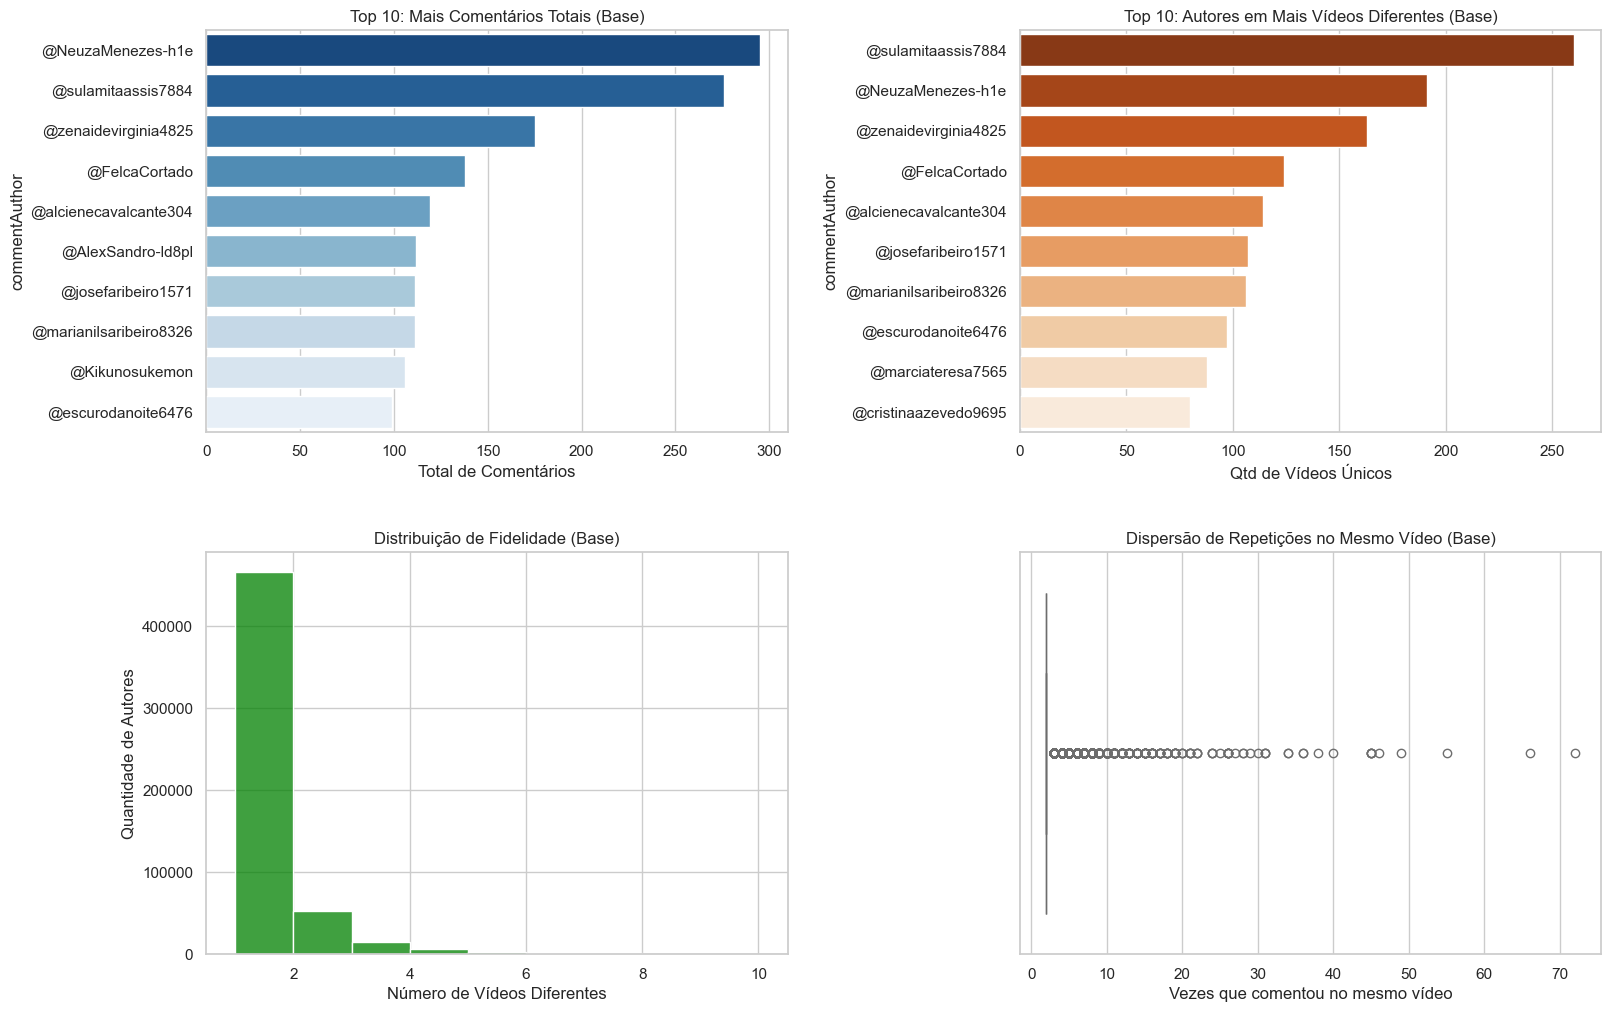

C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\2714666731.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\2714666731.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


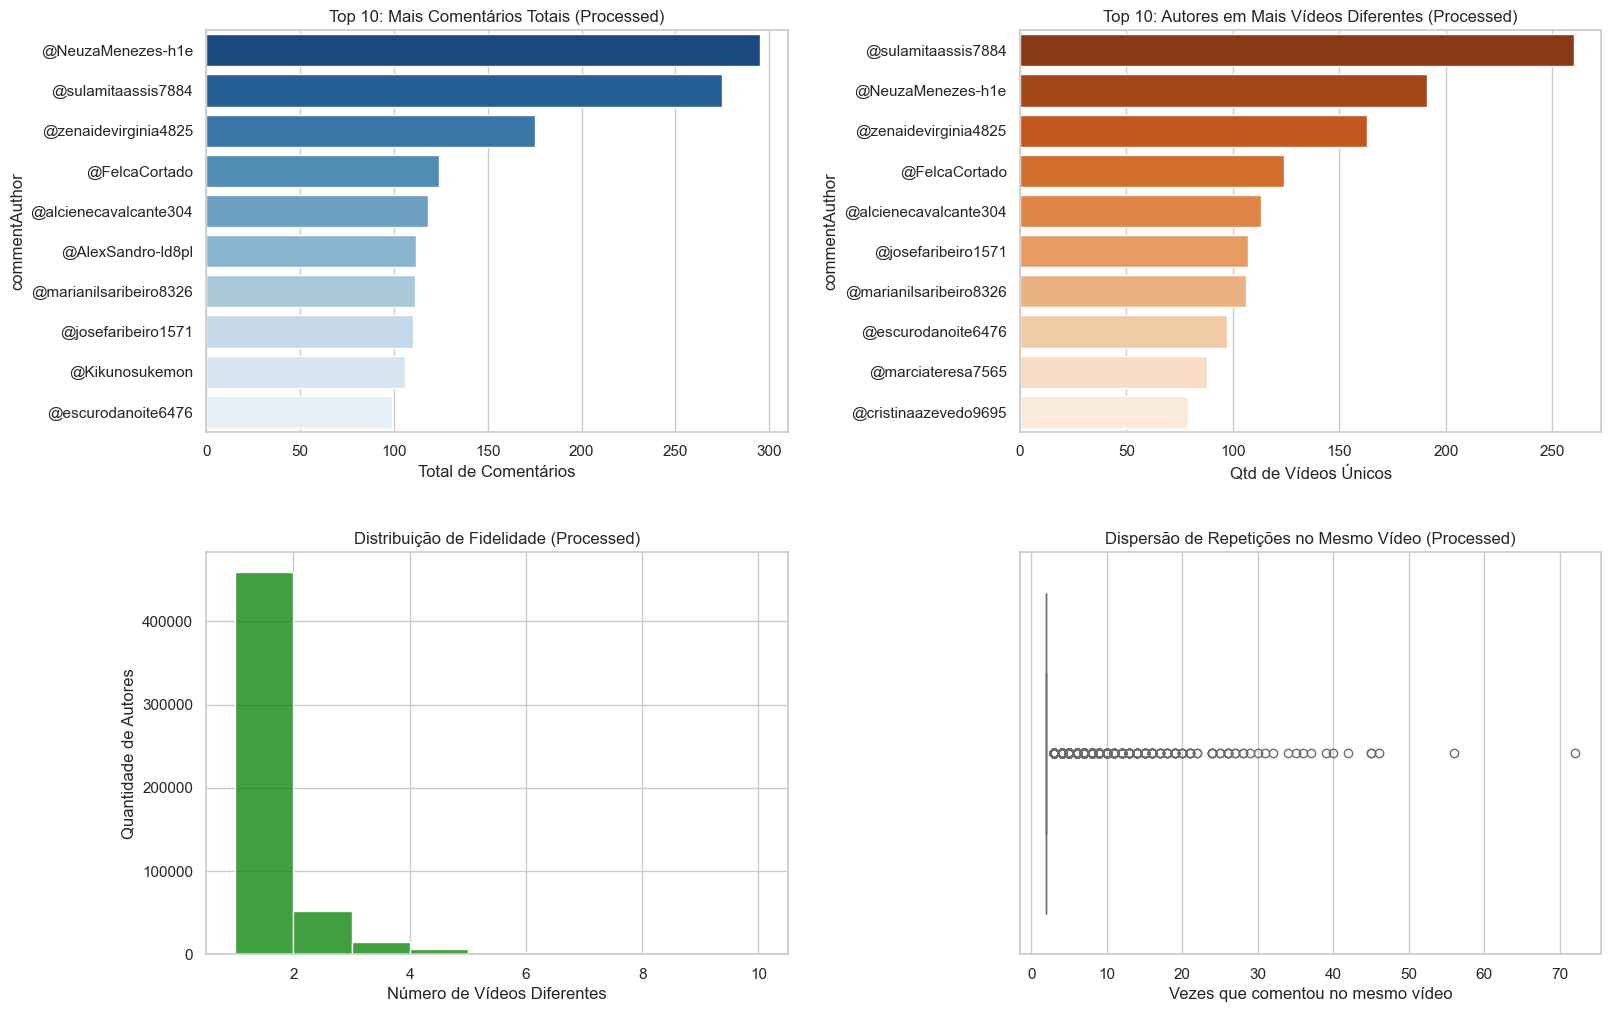

In [97]:
plot_author_metrics(comments_per_author_base, videos_per_author_base, authors_repeated_vid_base, "(Base)")

plot_author_metrics(comments_per_author_pr, videos_per_author_pr, authors_repeated_vid_pr, "(Processed)")

## Análise de Comprimento

* Contagem de caracteres
* Contagem de tokens (separação por espaço)
* Estatísticas de comprimento (Média, Mediana, Mínimo, Máximo, Desvio Padrão)

In [103]:
df_base['char_count'] = df_base['commentText'].apply(len)

df_base['token_count'] = df_base['commentText'].apply(lambda x: len(x.split()))

len_statistics_base = df_base[['char_count', 'token_count']].describe()

In [104]:
df_processed['char_count'] = df_processed['cleanedText'].apply(len)

df_processed['token_count'] = df_processed['cleanedText'].apply(lambda x: len(x.split()))

len_statistics_processed = df_processed[['char_count', 'token_count']].describe()

In [105]:
print("Estatísticas dataset não processado:")
print("=== Top 10 Autores mais ativos (Total de Comentários) ===")
print(comments_per_author_base.head(10))

print("\n=== Autores que mais comentaram em vídeos diferentes ===")
print(videos_per_author_base.head(10))

print("\n=== Estatísticas de Tamanho dos Comentários ===")
print(len_statistics_base)

print(f"\nMediana de caracteres: {df_base['char_count'].median()}")
print(f"Mediana de tokens: {df_base['token_count'].median()}")

Estatísticas dataset não processado:
=== Top 10 Autores mais ativos (Total de Comentários) ===
authorChannelId           commentAuthor         
UC5Yn8AO8ShtSJ2Zx6M7PCig  @NeuzaMenezes-h1e         295
UCcx4LCJegDRGeZEexmYBvsQ  @sulamitaassis7884        276
UCIf5p_T1HYWP4kj-aCpHNrw  @zenaidevirginia4825      175
UChFAYaVmYnFJhXXmkADjY3g  @FelcaCortado             138
UCjrGn0M7Lyh0149M9JblQkA  @alcienecavalcante304     119
UCVuy9xDNp5Tvq0e9n3PLwyQ  @AlexSandro-ld8pl         112
UCMsZYRh764v-XICS9y0srRw  @josefaribeiro1571        111
UC9WA6y2XpZh2UPxaQOD7CIg  @marianilsaribeiro8326    111
UCqsYcnnFNzPwyJaCQQRi7oA  @Kikunosukemon            106
UCW_MORbm5lM7BWozx4_X48w  @escurodanoite6476         99
dtype: int64

=== Autores que mais comentaram em vídeos diferentes ===
authorChannelId           commentAuthor         
UCcx4LCJegDRGeZEexmYBvsQ  @sulamitaassis7884        260
UC5Yn8AO8ShtSJ2Zx6M7PCig  @NeuzaMenezes-h1e         191
UCIf5p_T1HYWP4kj-aCpHNrw  @zenaidevirginia4825      163
UChFAYaV

In [106]:
print("Estatísticas dataset processado:")
print("=== Top 10 Autores mais ativos (Total de Comentários) ===")
print(comments_per_author_pr.head(10))

print("\n=== Autores que mais comentaram em vídeos diferentes ===")
print(videos_per_author_pr.head(10))

print("\n=== Estatísticas de Tamanho dos Comentários ===")
print(len_statistics_processed)

print(f"\nMediana de caracteres: {df_processed['char_count'].median()}")
print(f"Mediana de tokens: {df_processed['token_count'].median()}")

Estatísticas dataset processado:
=== Top 10 Autores mais ativos (Total de Comentários) ===
authorChannelId           commentAuthor         
UC5Yn8AO8ShtSJ2Zx6M7PCig  @NeuzaMenezes-h1e         295
UCcx4LCJegDRGeZEexmYBvsQ  @sulamitaassis7884        275
UCIf5p_T1HYWP4kj-aCpHNrw  @zenaidevirginia4825      175
UChFAYaVmYnFJhXXmkADjY3g  @FelcaCortado             124
UCjrGn0M7Lyh0149M9JblQkA  @alcienecavalcante304     118
UCVuy9xDNp5Tvq0e9n3PLwyQ  @AlexSandro-ld8pl         112
UC9WA6y2XpZh2UPxaQOD7CIg  @marianilsaribeiro8326    111
UCMsZYRh764v-XICS9y0srRw  @josefaribeiro1571        110
UCqsYcnnFNzPwyJaCQQRi7oA  @Kikunosukemon            106
UCW_MORbm5lM7BWozx4_X48w  @escurodanoite6476         99
dtype: int64

=== Autores que mais comentaram em vídeos diferentes ===
authorChannelId           commentAuthor         
UCcx4LCJegDRGeZEexmYBvsQ  @sulamitaassis7884        260
UC5Yn8AO8ShtSJ2Zx6M7PCig  @NeuzaMenezes-h1e         191
UCIf5p_T1HYWP4kj-aCpHNrw  @zenaidevirginia4825      163
UChFAYaVmYnF

## Gráficos

In [107]:
# Configuração do visual

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Preparar dados temporais

In [108]:
df_base['commentPublishedAt'] = pd.to_datetime(df_base['commentPublishedAt'])
df_base['hour'] = df_base['commentPublishedAt'].dt.hour
df_base['day_of_week'] = df_base['commentPublishedAt'].dt.day_name()

df_processed['commentPublishedAt'] = pd.to_datetime(df_processed['commentPublishedAt'])
df_processed['hour'] = df_processed['commentPublishedAt'].dt.hour
df_processed['day_of_week'] = df_processed['commentPublishedAt'].dt.day_name()

### Distribuição de Comentários por Hora do Dia

In [109]:
def comment_distribution_hour_graph(df):
    plt.figure()
    sns.countplot(data=df, x='hour', palette='viridis')
    plt.title('Volume de Comentários por Hora do Dia')
    plt.xlabel('Hora (0-23h)')
    plt.ylabel('Total de Comentários')
    #plt.savefig('comentarios_por_hora.png')

Gráfico de distribuição de comentários por hora do dia do dataset não processado:


C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\1968725503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour', palette='viridis')



Gráfico de distribuição de comentários por hora do dia do dataset processado:


C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\1968725503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour', palette='viridis')


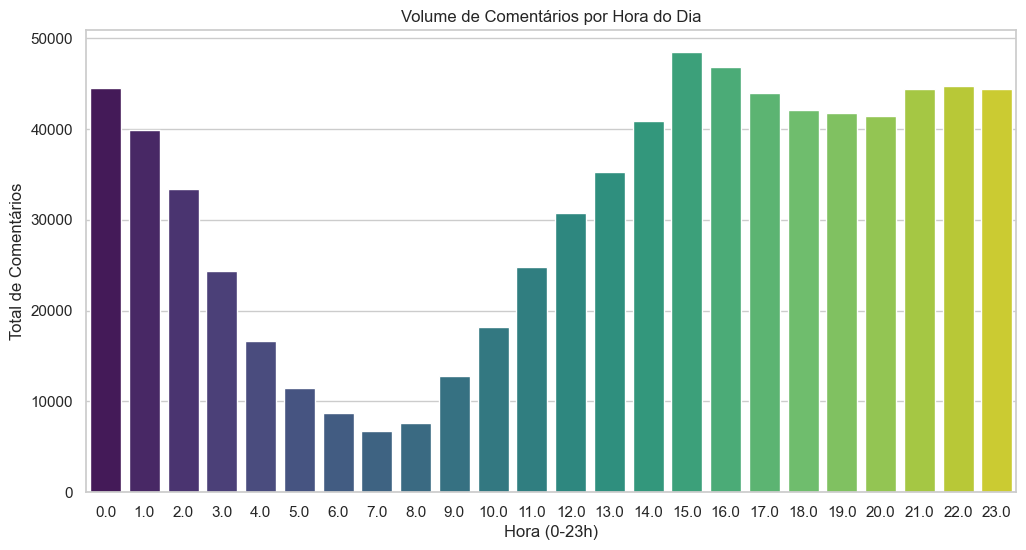

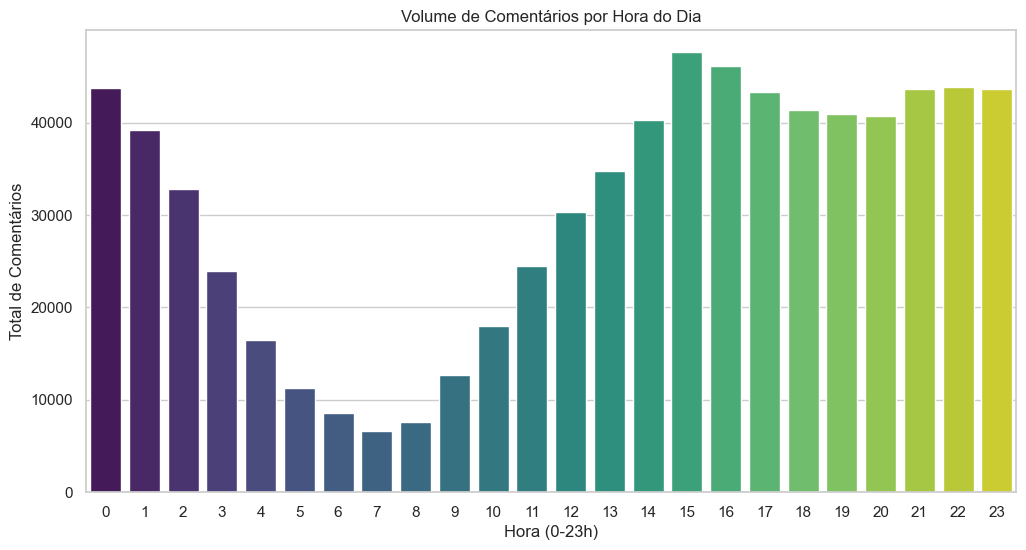

In [110]:
print("Gráfico de distribuição de comentários por hora do dia do dataset não processado:")
comment_distribution_hour_graph(df_base)
print()

print("Gráfico de distribuição de comentários por hora do dia do dataset processado:")
comment_distribution_hour_graph(df_processed)

### Top 10 Vídeos com Mais Comentários

In [111]:
def top_commented_videos_graph(df):
    plt.figure()
    top_videos = df['videoId'].value_counts().head(10)
    sns.barplot(x=top_videos.values, y=top_videos.index, palette='magma')
    plt.title('Top 10 Vídeos Mais Comentados')
    plt.xlabel('Número de Comentários')
    #plt.savefig('top_videos.png')

Top 10 videos mais comentados dataset não processado:

Top 10 videos mais comentados dataset processado:


C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\2489497811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_videos.values, y=top_videos.index, palette='magma')
C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\2489497811.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_videos.values, y=top_videos.index, palette='magma')


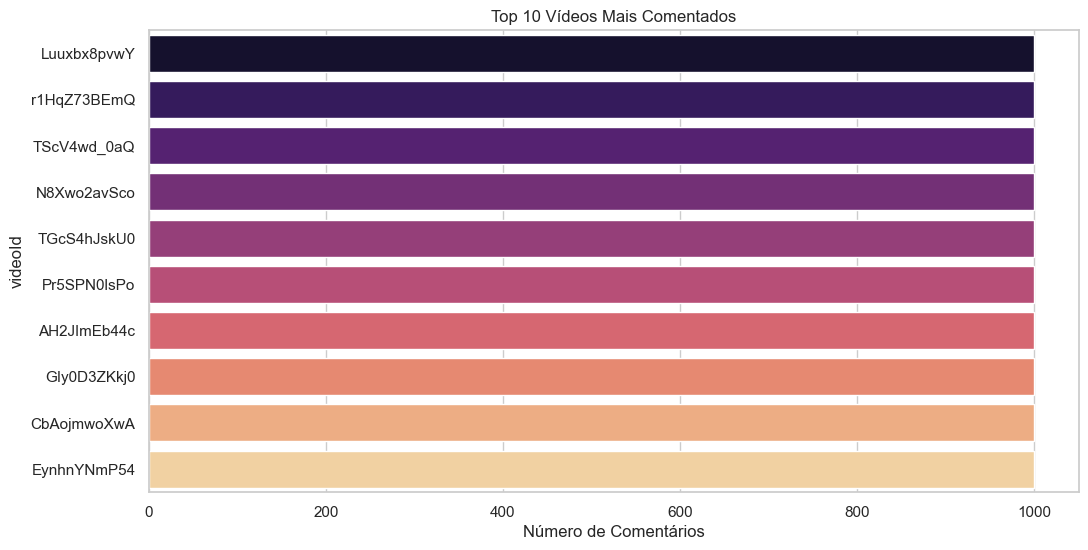

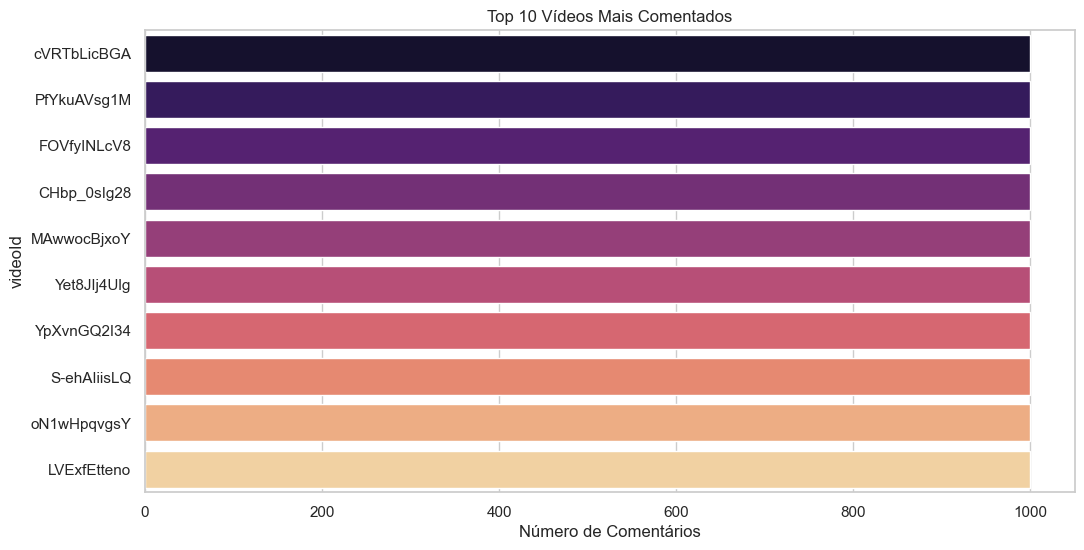

In [112]:
print("Top 10 videos mais comentados dataset não processado:")
top_commented_videos_graph(df_base)
print()

print("Top 10 videos mais comentados dataset processado:")
top_commented_videos_graph(df_processed)

### Correlação entre Likes e Respostas

In [113]:
def likes_replies_correlation_graph(df):
    plt.figure()
    sns.scatterplot(data=df, x='commentLikeCount', y='commentReplyCount', alpha=0.5)
    plt.title('Correlação: Likes vs. Respostas (Replies)')
    plt.xlabel('Quantidade de Likes')
    plt.ylabel('Quantidade de Respostas')
    # Aplicar escala logarítmica se houver muitos outliers
    # plt.xscale('log'); plt.yscale('log')
    #plt.savefig('correlacao_engajamento.png')

Gráfico de correlação entre likes e respostas no dataset não processado:

Gráfico de correlação entre likes e respostas no dataset processado:


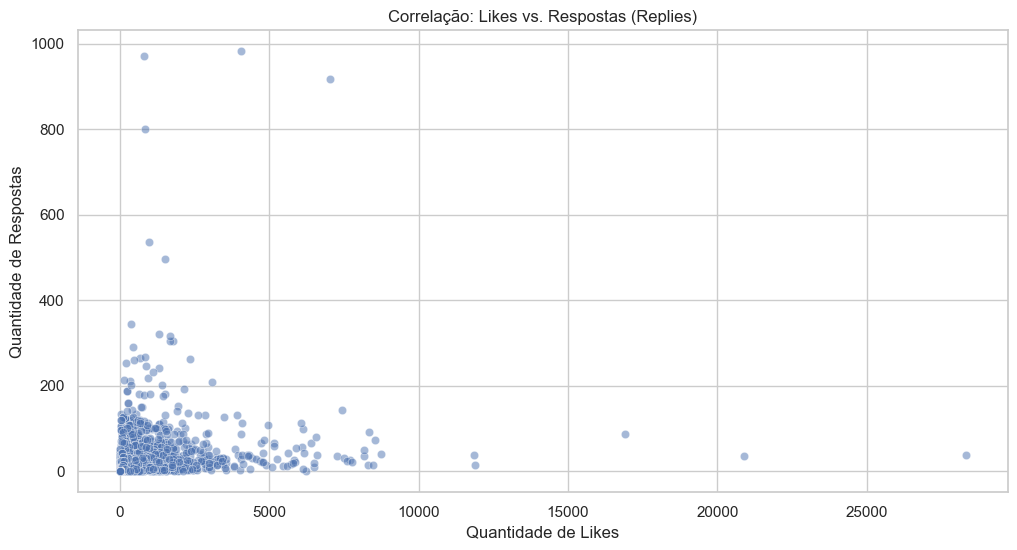

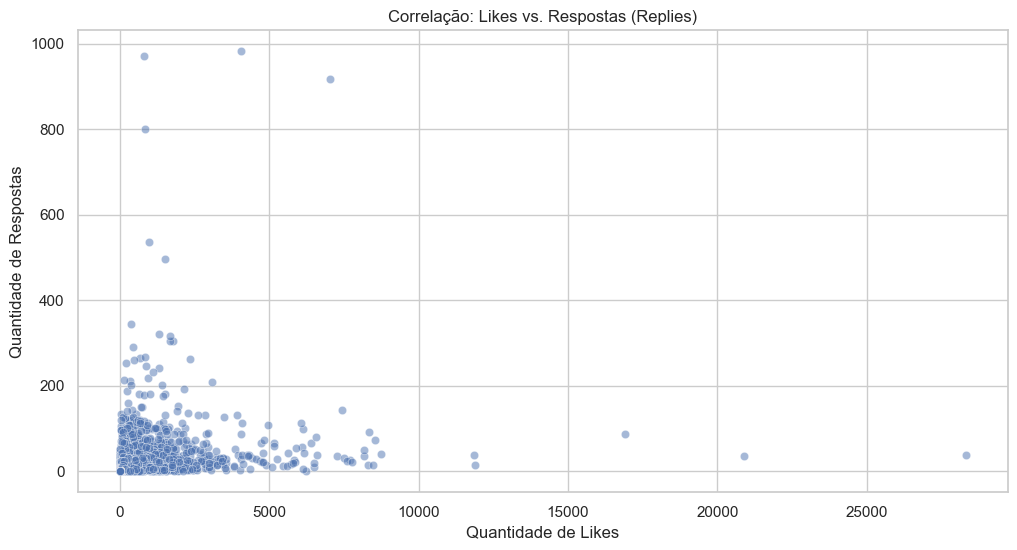

In [114]:
print("Gráfico de correlação entre likes e respostas no dataset não processado:")
likes_replies_correlation_graph(df_base)
print()

print("Gráfico de correlação entre likes e respostas no dataset processado:")
likes_replies_correlation_graph(df_processed)

### Distribuição do Tamanho dos Comentários (Tokens)

In [122]:
def token_distribution_graph(df):
    plt.figure()

    sns.histplot(df['token_count'], bins=50, kde=True, color='skyblue')
    plt.title('Distribuição da Quantidade de Palavras por Comentário')
    plt.xlabel('Número de Palavras')
    plt.ylabel('Frequência')
    plt.xlim(0, df['token_count'].quantile(0.95)) # Limita a 95% para ignorar textos gigantes
    #plt.savefig('distribuicao_tamanho.png')

Gráfico de distribuição do tamanho dos comentários do dataset não processado:

Gráfico de distribuição do tamanho dos comentários do dataset processado:


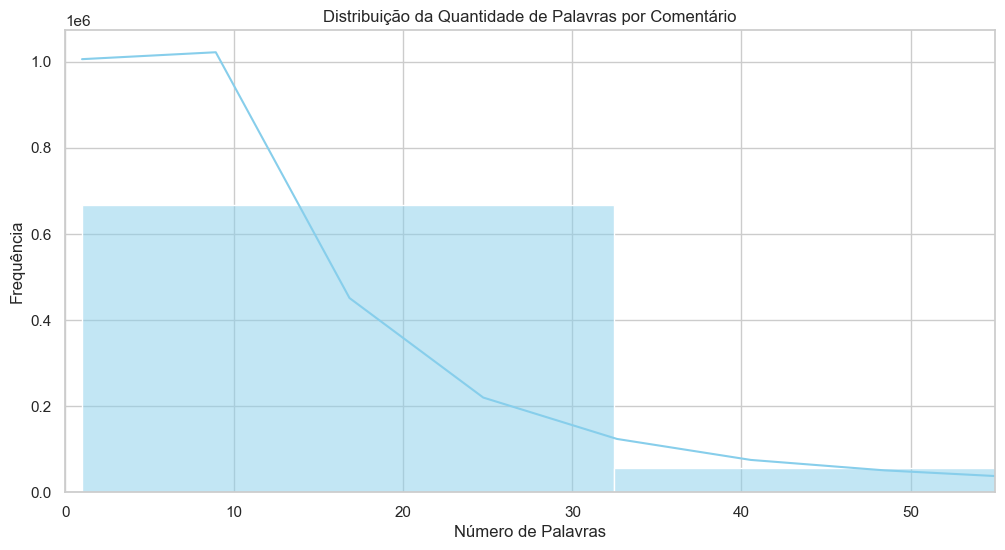

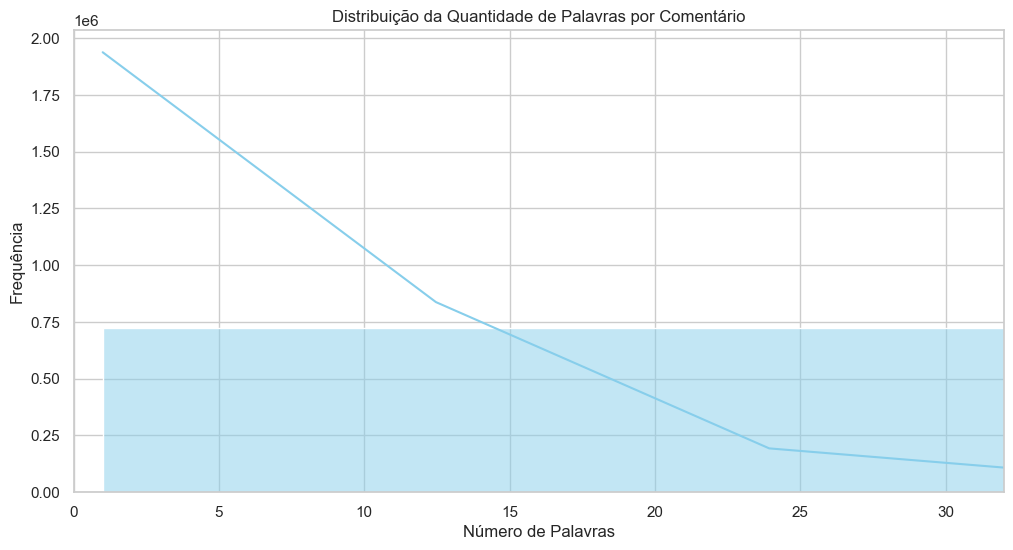

In [123]:
print("Gráfico de distribuição do tamanho dos comentários do dataset não processado:")
token_distribution_graph(df_base)
print()

print("Gráfico de distribuição do tamanho dos comentários do dataset processado:")
token_distribution_graph(df_processed)

## Extras

* Taxa de engajamento por autor
* Percentual de comentários com respostas
* Detectar spans ou bots

In [124]:
author_engagement_base = df_base.groupby('commentAuthor')['commentLikeCount'].mean().sort_values(ascending=False)

author_engagement_pr = df_processed.groupby('commentAuthor')['commentLikeCount'].mean().sort_values(ascending=False)

In [125]:
pct_dialoge_base = (df_base['commentReplyCount'] > 0).mean() * 100
print(f"Porcentagem de comentários que geraram conversa dataset não processado: {pct_dialoge_base:.2f}%")

pct_dialoge_pr = (df_processed['commentReplyCount'] > 0).mean() * 100
print(f"Porcentagem de comentários que geraram conversa dataset processado: {pct_dialoge_pr:.2f}%")

Porcentagem de comentários que geraram conversa dataset não processado: 10.93%
Porcentagem de comentários que geraram conversa dataset processado: 11.03%


In [119]:
possible_spam_base = df_base.groupby(['authorChannelId', 'commentText']).size().reset_index(name='repeticoes')
possible_spam_base = possible_spam_base[possible_spam_base['repeticoes'] > 3].sort_values(by='repeticoes', ascending=False)

possible_spam_pr = df_processed.groupby(['authorChannelId', 'cleanedText']).size().reset_index(name='repeticoes')
possible_spam_pr = possible_spam_pr[possible_spam_pr['repeticoes'] > 3].sort_values(by='repeticoes', ascending=False)

### Gráfico de Barras

In [129]:
def plot_spam_ranking(df_spam, column_text, title="Top Mensagens Repetidas"):
    plt.figure(figsize=(10, 6))
    top_10_spam = df_spam.head(10).copy()
    
    top_10_spam['label'] = top_10_spam[column_text].str[:20] + "... (ID: " + top_10_spam['authorChannelId'].str[:5] + ")"

    sns.barplot(data=top_10_spam, x='repeticoes', y='label', palette='Reds_r')
    plt.title(title)
    plt.xlabel('Número de Vezes que a Mensagem foi Repetida')
    plt.ylabel('Início da Mensagem / Autor')
    plt.show()

C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\2647631899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_spam, x='repeticoes', y='label', palette='Reds_r')
C:\Users\Nathan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128079 (\N{CLAPPING HANDS SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Nathan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10084 (\N{HEAVY BLACK HEART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Nathan\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


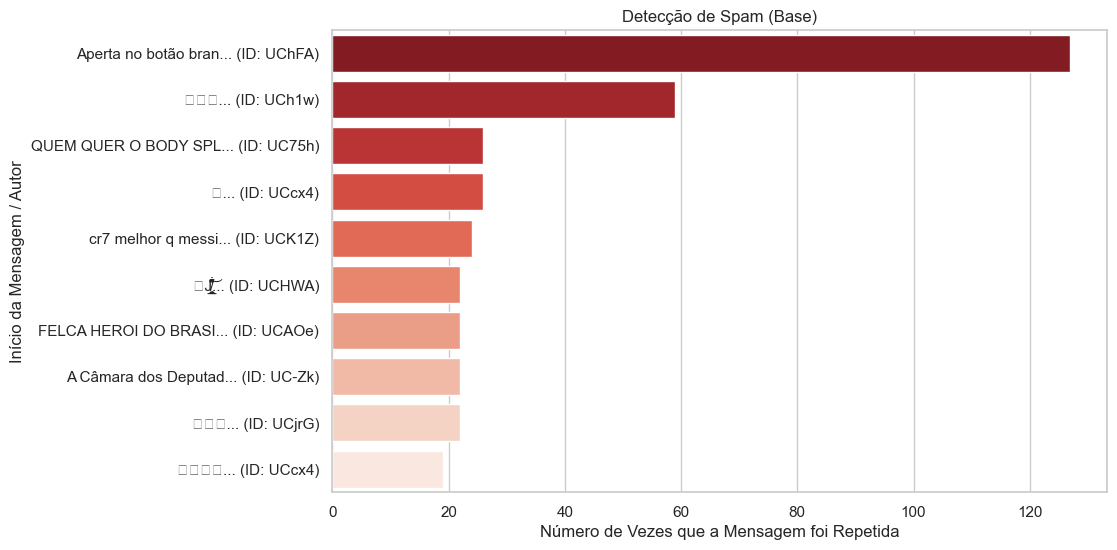

C:\Users\Nathan\AppData\Local\Temp\ipykernel_2440\2647631899.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_spam, x='repeticoes', y='label', palette='Reds_r')


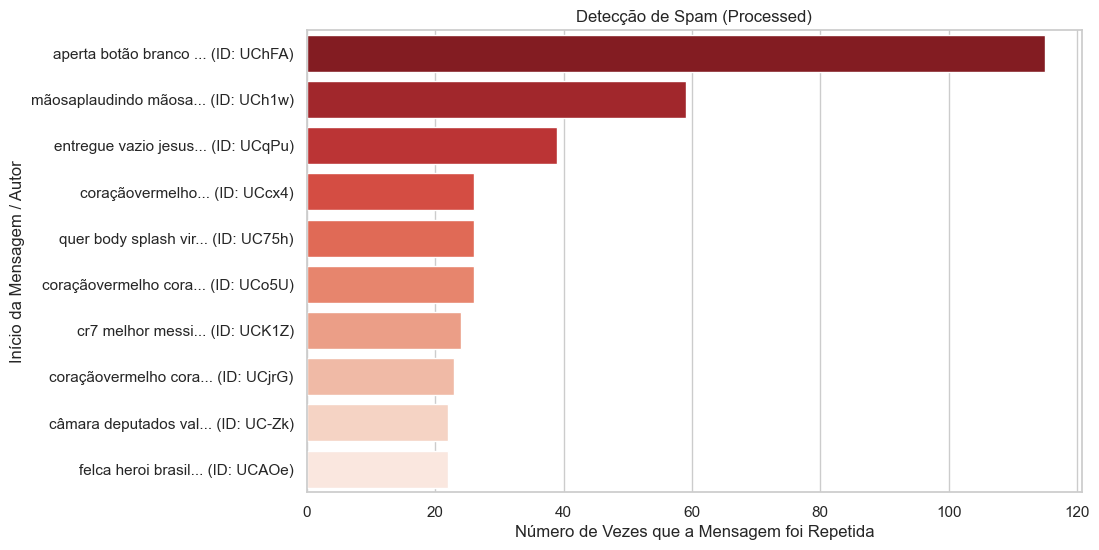

In [130]:
plot_spam_ranking(possible_spam_base, 'commentText', "Detecção de Spam (Base)")
print()

plot_spam_ranking(possible_spam_pr, 'cleanedText', "Detecção de Spam (Processed)")

In [140]:
def histogram_freq_rep(possible_spam):
    plt.figure(figsize=(8, 5))
    sns.histplot(possible_spam['repeticoes'], bins=30, kde=True, color='darkred')
    plt.title('Distribuição da Intensidade de Repetição')
    plt.xlabel('Quantidade de Repetições da Mesma Mensagem')
    plt.ylabel('Contagem de Casos')
    plt.show()

Dataset não processado


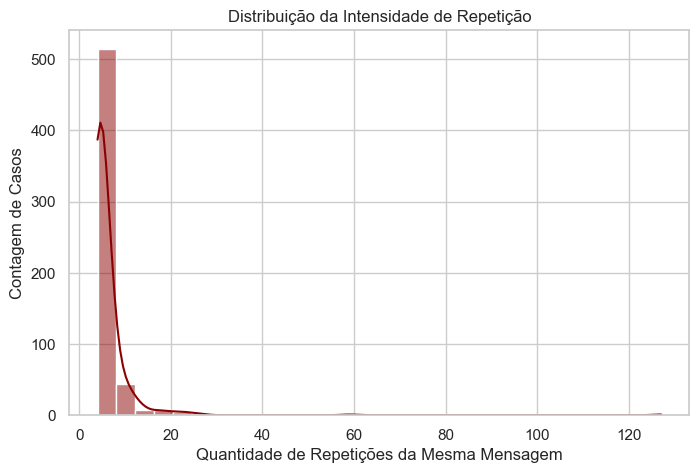


Dataset processado


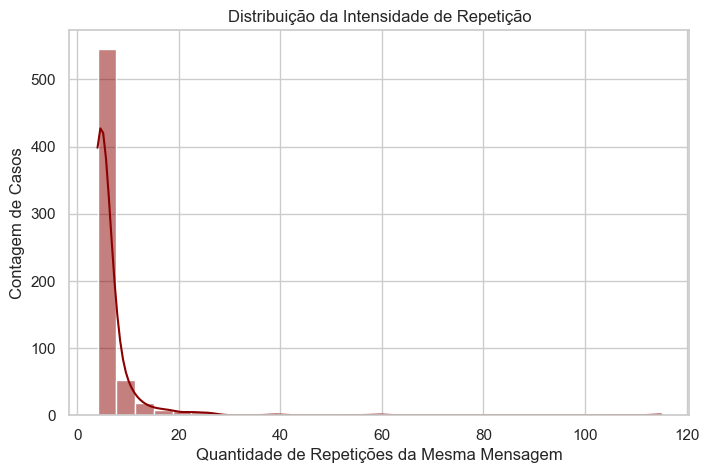

In [141]:
print("Dataset não processado")
histogram_freq_rep(possible_spam_base)
print()

print("Dataset processado")
histogram_freq_rep(possible_spam_pr)

## Nuvem de Palavras

In [142]:
from wordcloud import WordCloud, STOPWORDS

In [143]:
texts_base = df_base['commentText'].astype(str).values
complete_text_base = " ".join(comment for comment in texts_base)

texts_processed = df_processed['cleanedText'].astype(str).values
complete_text_processed = " ".join(comment for comment in texts_processed)

In [146]:
stop_words_pt = set(STOPWORDS)
stop_words_pt.update([
    "que", "de", "do", "da", "em", "um", "para", "é", "com", "não", "uma", "os", "no", 
    "se", "na", "por", "mais", "as", "dos", "como", "mas", "foi", "ao", "ele", "das", 
    "tem", "à", "seu", "sua", "ou", "ser", "quando", "muito", "há", "nos", "já", "está",
    "video", "canal", "vcs", "você", "comentário", "youtube",
])

In [148]:
cloud_base = WordCloud(
    width=1600, 
    height=800,
    background_color='white',
    stopwords=stop_words_pt,
    colormap='viridis',
    max_words=100,
    min_font_size=10
).generate(complete_text_base)

cloud_processed = WordCloud(
    width=1600, 
    height=800,
    background_color='white',
    stopwords=stop_words_pt,
    colormap='viridis',
    max_words=100,
    min_font_size=10
).generate(complete_text_processed)

In [147]:
def display_cloud(cloud):
    plt.figure(figsize=(20, 10), facecolor=None)
    plt.imshow(cloud, interpolation='bilinear')
    plt.axis("off")
    plt.tight_layout(pad=0)

    plt.show()

Nuvem de palavras do dataset não processado:


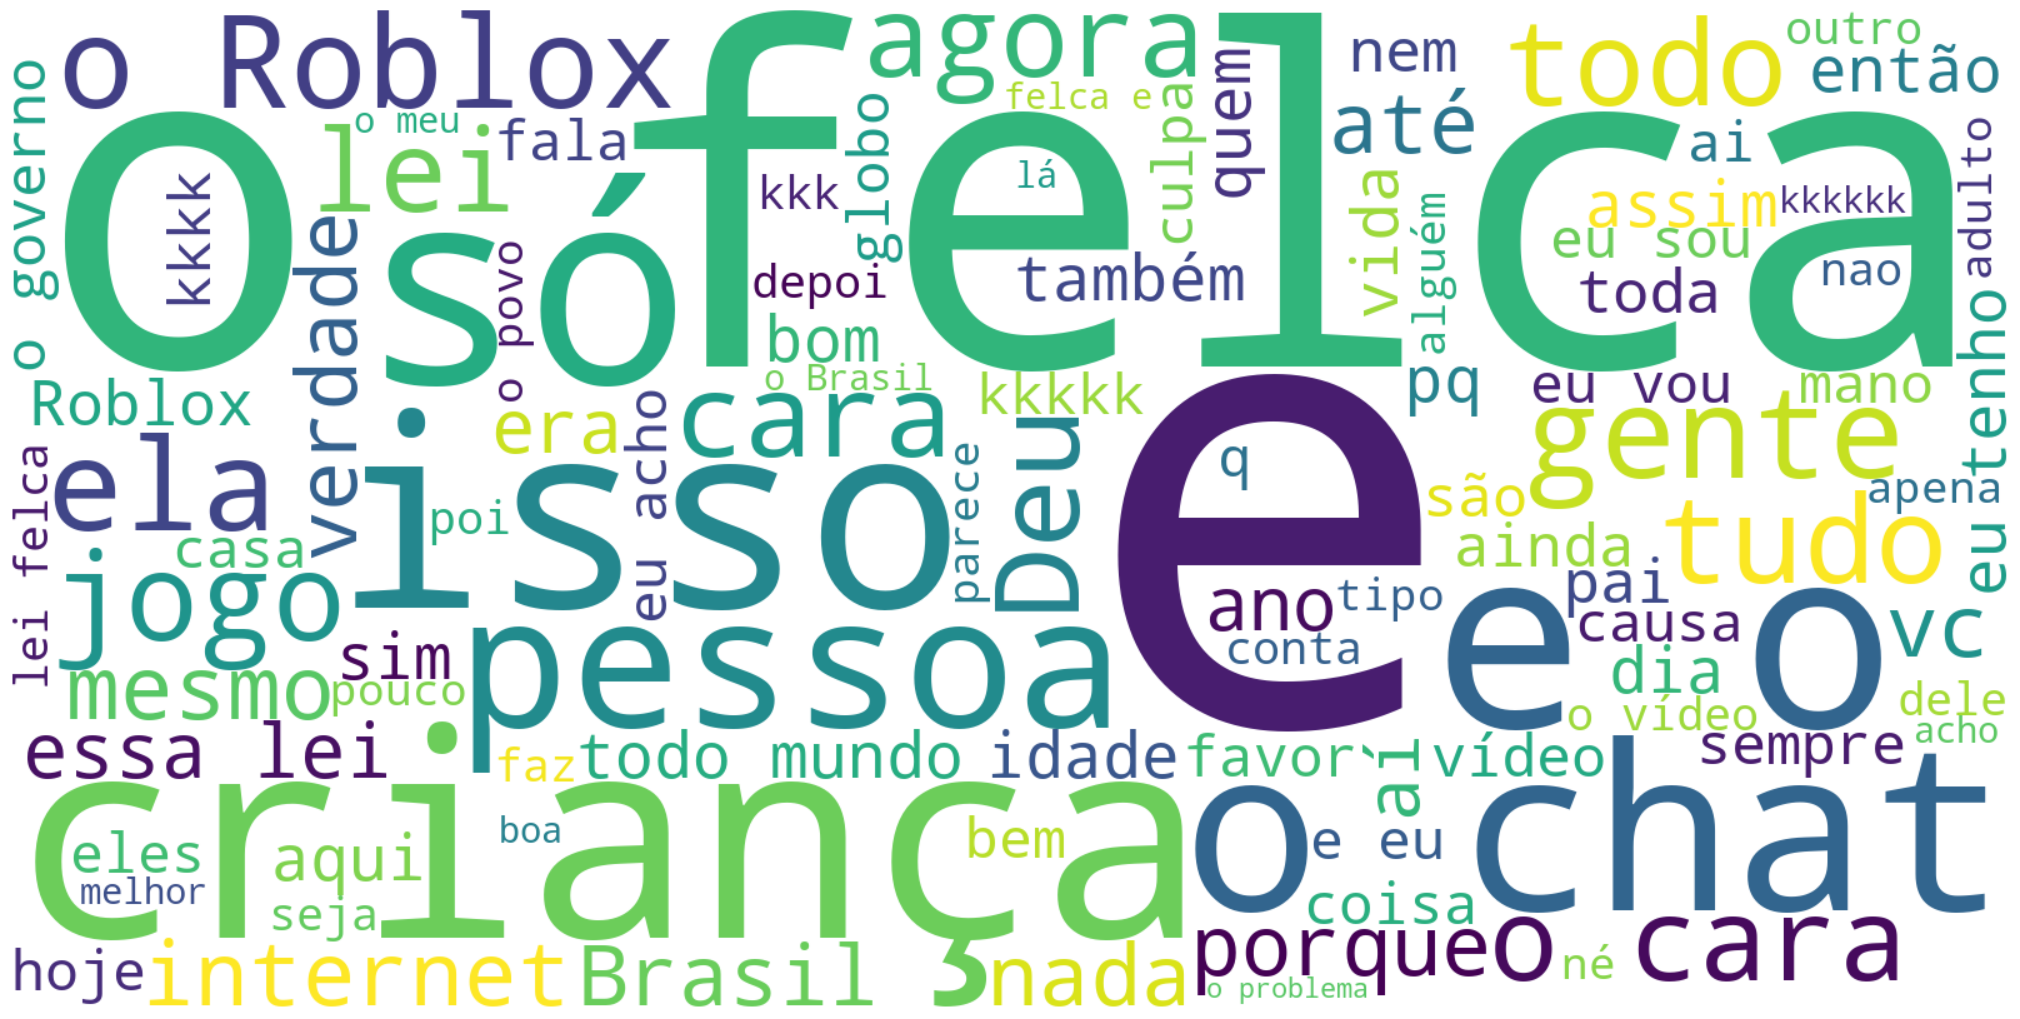


Nuvem de palavras do dataset processado:


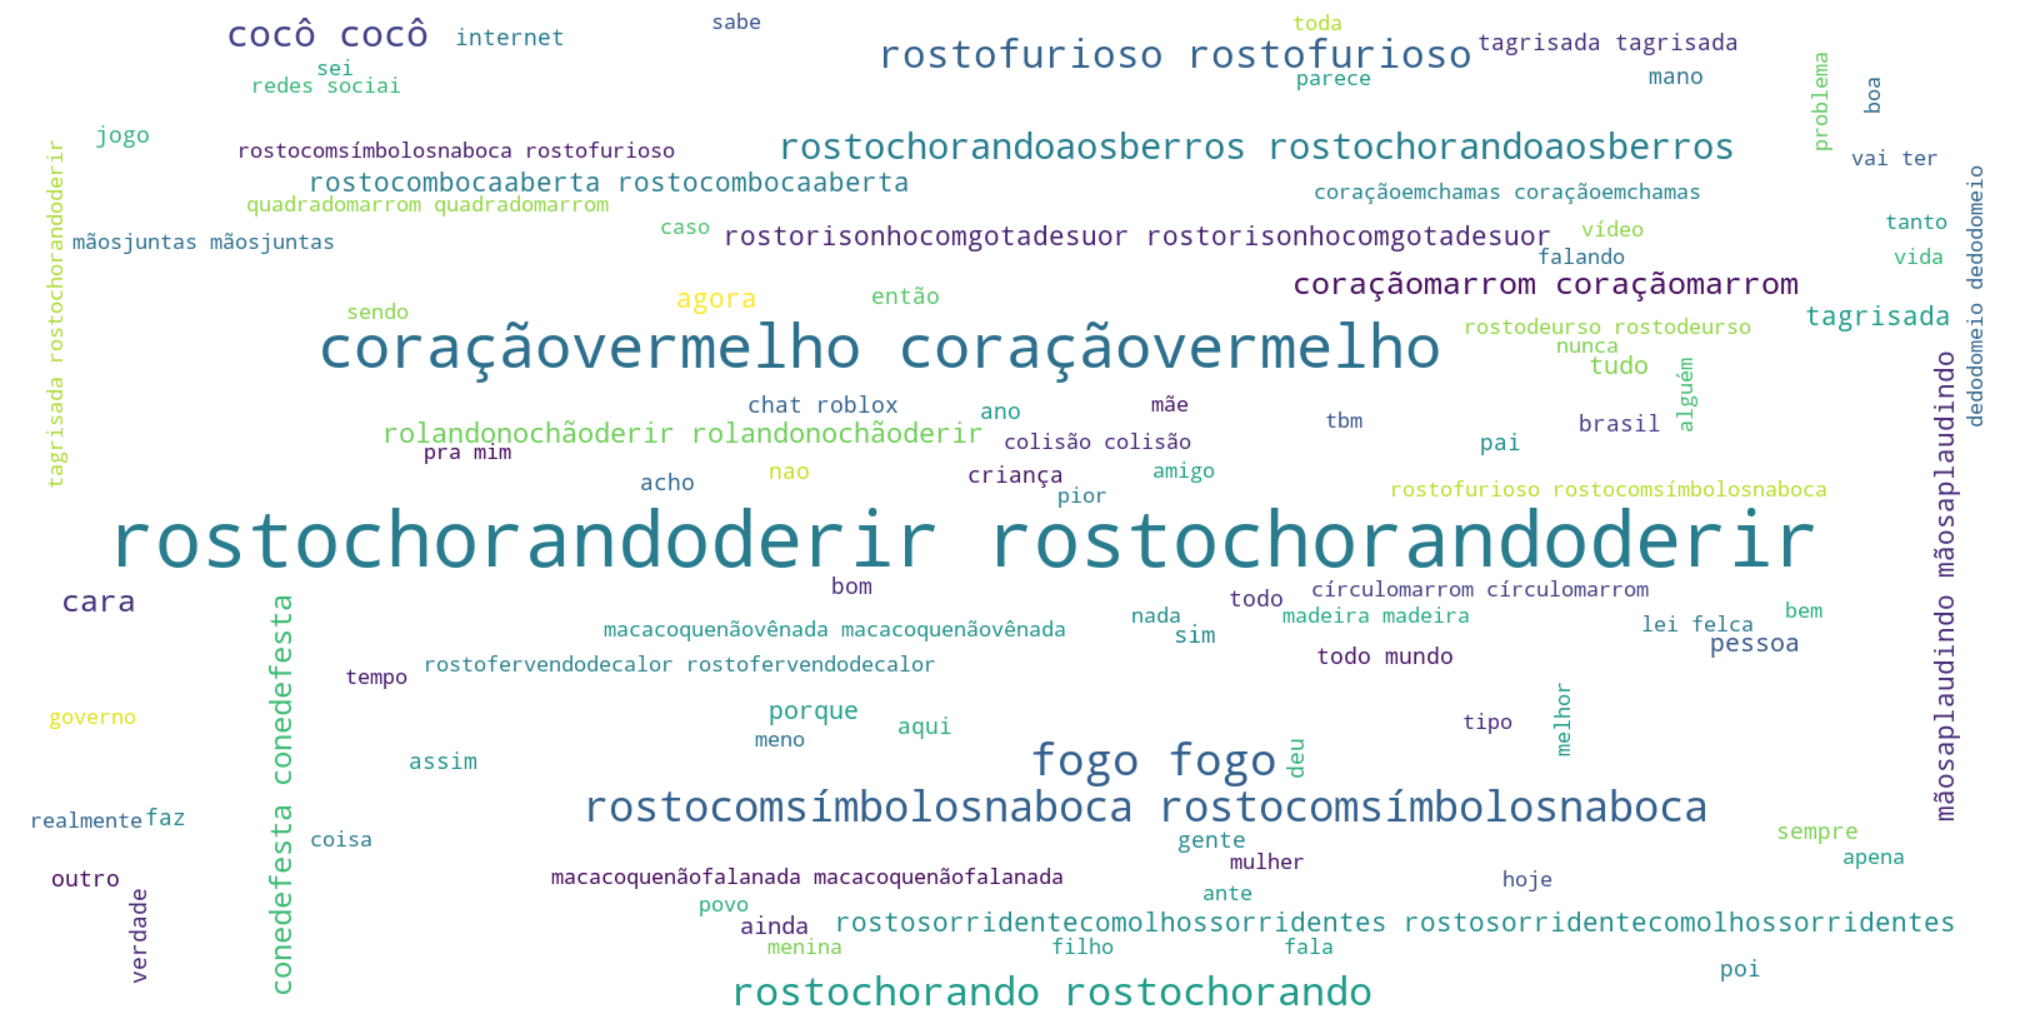

In [149]:
print("Nuvem de palavras do dataset não processado:")
display_cloud(cloud_base)
print()

print("Nuvem de palavras do dataset processado:")
display_cloud(cloud_processed)